In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from autoenkoop import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
file = np.load("../../data/T1492_x1151_y1_z127_c2.npz")
data = file['timeseries']

In [3]:
class VelocityDataset(Dataset):
    def __init__(self, data):
        # data: numpy array of shape (t, x, z, v)
        self.X = torch.tensor(data[:-1], dtype=torch.float32).permute(0,3,1,2)
        self.Y = torch.tensor(data[1:], dtype=torch.float32).permute(0,3,1,2)
        # Now shape: (t, v=2, x=1151, z=127)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [4]:
dataset = VelocityDataset(data)
loader = DataLoader(dataset, batch_size=12, shuffle=True)

In [ ]:
model = ConvAutoencoder(latent_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

n_epochs = 200

loss_reconstruction_history = np.zeros((n_epochs))
loss_prediction_history = np.zeros((n_epochs))
loss_linearity_history = np.zeros((n_epochs))
loss_total_history = np.zeros((n_epochs))
steady_mode_number_history = np.zeros((n_epochs))

steady_tolerance = 0.01

def calculate_dynamic_weight(x_t, x_t_reconstructed, x_t_plus_1, x_t_plus_1_reconstructed, alpha = 10):
    with torch.no_grad():
        reconSq_diff_x_t = (x_t.cpu() - x_t_reconstructed.cpu())**2
        reconSq_diff_x_t_plus_1 = (x_t_plus_1.cpu() - x_t_plus_1_reconstructed.cpu())**2
        recon_mse_example_x_t = torch.mean(reconSq_diff_x_t,dim=[1,2,3])
        recon_mse_example_x_t_plus_1 = torch.mean(reconSq_diff_x_t_plus_1,dim=[1,2,3])
        recon_mse_example = recon_mse_example_x_t + recon_mse_example_x_t_plus_1
        dyn_weight_example = np.exp(-alpha*recon_mse_example.cpu().numpy())
    return dyn_weight_example

for epoch in range(n_epochs):

    if epoch % 20 == 0:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    
    reconstruction_loss_epoch = 0.0
    prediction_loss_epoch = 0.0
    linearity_loss_epoch = 0.0
    total_loss_epoch = 0.0
    lin_dyn_weight_epoch = 0.0

    for x_t, x_t_plus_1 in loader:
        x_t, x_t_plus_1 = x_t.to(DEVICE), x_t_plus_1.to(DEVICE)
        batch_size = x_t.size(0)

        optimizer.zero_grad()
        
        #encoded current state
        z_t = model.encoder(x_t)
        #decoded current state
        reconstructed_x_t = model.decoder(z_t)
        #linear projected encoded next state
        pz_t_plus_1 = model.linear_dynamics(z_t)

        #encoded next state
        z_t_plus_1 = model.encoder(x_t_plus_1)
        reconstructed_x_t_plus_1 = model.decoder(z_t_plus_1)

        ### RECONSTRUCTION LOSS ###
        loss_reconstruction = mse(x_t, reconstructed_x_t) + mse(x_t_plus_1, reconstructed_x_t_plus_1)
        lin_dyn_weight_test = calculate_dynamic_weight(x_t, reconstructed_x_t, x_t_plus_1, reconstructed_x_t_plus_1, alpha=10)
        lin_dyn_weight_epoch += sum(lin_dyn_weight_test)

        #projected decoded next state
        reconstructed_px_t_plus_1 = model.decoder(pz_t_plus_1)

        ### PREDICTION LOSS ###
        loss_prediction = mse(reconstructed_px_t_plus_1, x_t_plus_1)

        ### LINEARITY LOSS ###
        error_linearity = (pz_t_plus_1 - z_t_plus_1)**2
        loss_linearity = torch.mean(torch.mean(error_linearity,dim=[1]) * torch.tensor(lin_dyn_weight_test).to(DEVICE))

        ### TOTAL LOSS ###
        loss_total = loss_reconstruction + loss_prediction + loss_linearity

        loss_total.backward()
        optimizer.step()
        
        
        reconstruction_loss_epoch += loss_reconstruction.item() * batch_size
        prediction_loss_epoch += loss_prediction.item() * batch_size
        linearity_loss_epoch += loss_linearity.item() * batch_size
        total_loss_epoch += loss_total.item() * batch_size

    # calculate epoch loss mean
    num_examples = len(loader.dataset)

    reconstruction_loss_mean = reconstruction_loss_epoch / num_examples
    prediction_loss_mean = prediction_loss_epoch / num_examples
    linearity_loss_mean = linearity_loss_epoch / num_examples
    total_loss_mean = total_loss_epoch / num_examples
    lin_dyn_weight_mean = lin_dyn_weight_epoch / num_examples

    
    loss_reconstruction_history[epoch] = reconstruction_loss_mean
    loss_prediction_history[epoch] = prediction_loss_mean
    loss_linearity_history[epoch] = linearity_loss_mean
    loss_total_history[epoch] = total_loss_mean

    with torch.no_grad():
        K = model.linear_dynamics.weight.detach().cpu().numpy()
    eigvals, eigvecs = np.linalg.eig(K)
    
    max_abs_eigenvalue = np.max(np.abs(eigvals))

    mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
    steady_mode_number_history[epoch] = sum(mask)
        #break
    print(f"Epoch {epoch+1}/{n_epochs}\tLoss(total): {total_loss_mean:.4f}\tLoss(recon): {reconstruction_loss_mean:.4f}\tLoss(pred): {prediction_loss_mean:.4f}\tLoss(lin): {linearity_loss_mean:.6f}\tMaxAbsEigenV: {max_abs_eigenvalue:.4f}\tSteadyModes: {sum(mask)}\tLinDynWeight: {lin_dyn_weight_mean:.6f}")

Epoch 1/200	Loss(total): 1.6407	Loss(recon): 1.0828	Loss(pred): 0.5443	Loss(lin): 0.013668	MaxAbsEigenV: 1.0228	SteadyModes: 4	LinDynWeight: 0.001839
Epoch 2/200	Loss(total): 0.4082	Loss(recon): 0.2549	Loss(pred): 0.1288	Loss(lin): 0.024533	MaxAbsEigenV: 1.0043	SteadyModes: 5	LinDynWeight: 0.102194
Epoch 3/200	Loss(total): 0.2432	Loss(recon): 0.1551	Loss(pred): 0.0785	Loss(lin): 0.009665	MaxAbsEigenV: 1.0085	SteadyModes: 4	LinDynWeight: 0.221342
Epoch 4/200	Loss(total): 0.2027	Loss(recon): 0.1292	Loss(pred): 0.0656	Loss(lin): 0.007885	MaxAbsEigenV: 1.0057	SteadyModes: 9	LinDynWeight: 0.280883
Epoch 5/200	Loss(total): 0.1751	Loss(recon): 0.1114	Loss(pred): 0.0566	Loss(lin): 0.007087	MaxAbsEigenV: 1.0006	SteadyModes: 8	LinDynWeight: 0.333431
Epoch 6/200	Loss(total): 0.1558	Loss(recon): 0.0986	Loss(pred): 0.0502	Loss(lin): 0.006904	MaxAbsEigenV: 1.0084	SteadyModes: 6	LinDynWeight: 0.377664
Epoch 7/200	Loss(total): 0.1409	Loss(recon): 0.0888	Loss(pred): 0.0453	Loss(lin): 0.006842	MaxAbsEig

In [27]:
torch.save(model.state_dict(), "model_20260206_1500.pt")

In [7]:
with torch.no_grad():
    K = model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = np.linalg.eig(K)

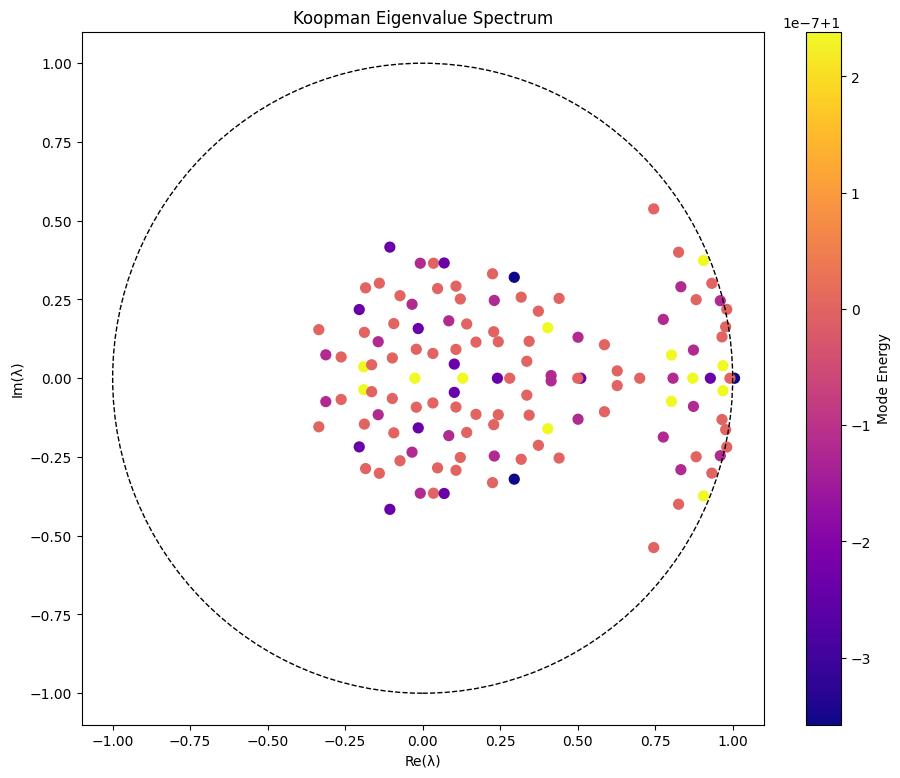

In [8]:
energies = np.linalg.norm(eigvecs, axis=0)**2
total_energy = np.sum(energies)

plt.figure(figsize=(11,9))
plt.axis([-1.1, 1.1, -1.1, 1.1])
sc = plt.scatter(np.real(eigvals), np.imag(eigvals),
                 c=energies, cmap='plasma', s=50)
plt.colorbar(sc, label="Mode Energy")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Koopman Eigenvalue Spectrum")
circle = plt.Circle((0,0), 1.0, color='k', fill=False, linestyle='--')
plt.gca().add_artist(circle)
#plt.axis('equal')
plt.show()

In [12]:
steady_tolerance = 0.02
# 0.002 => 3
# 0.003 => 7
# 0.004 => 11
# 0.005 => 13
# 0.006 => 15
# 0.01125 => 17
# 0.03 => 21

mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
eigvals_nondecay = eigvals[mask]
modes_nondecay = eigvecs[:, mask]

nondecay_energy = np.linalg.norm(modes_nondecay, axis=0)**2

explained_energy_ratio = np.sum(nondecay_energy / total_energy)
print(f"{sum(mask)} stable mode explain: {explained_energy_ratio:.3f}% of the energy")

# to torch cuda
E_nondecay = torch.tensor(eigvals_nondecay, dtype=torch.complex64,device=DEVICE)
E_nondecay_normalized = E_nondecay / torch.abs(E_nondecay)
V_nondecay = torch.tensor(modes_nondecay, dtype=torch.complex64, device=DEVICE)

10 stable mode explain: 0.078% of the energy


In [13]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay_normalized) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

In [21]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(1500):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

vx_all = data[..., 0]
vz_all = data[..., 1]

vx_min, vx_max = np.min(vx_all), np.max(vx_all)
vz_min, vz_max = np.min(vz_all), np.max(vz_all)

norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

def plot_vx_vz(vx, vz):

    plt.figure(figsize=(10,8))

    # --- vx ---
    plt.subplot(2,1,1)
    plt.imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
    plt.colorbar(label='vx')
    plt.title(f"vx")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    # --- vz ---
    plt.subplot(2,1,2)
    plt.imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
    plt.colorbar(label='vz')
    plt.title(f"vz")
    plt.xlabel("x-coordinate")
    plt.ylabel("z-coordinate")

    plt.tight_layout()
    plt.show()


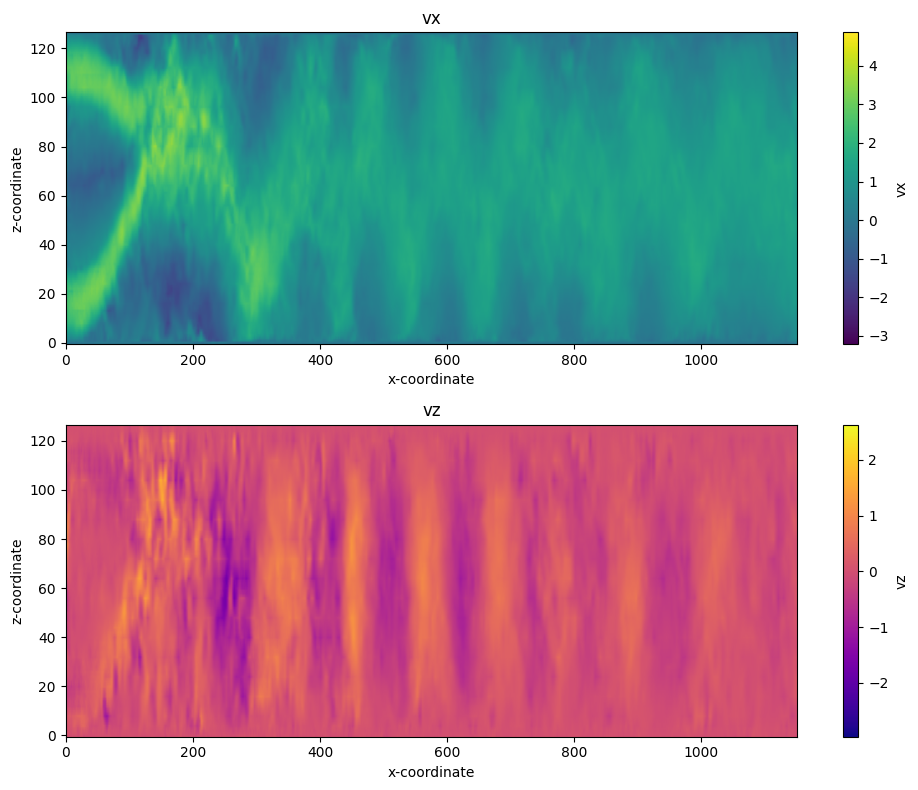

In [24]:
x_t_stable = steady_state_prediction[1499]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276


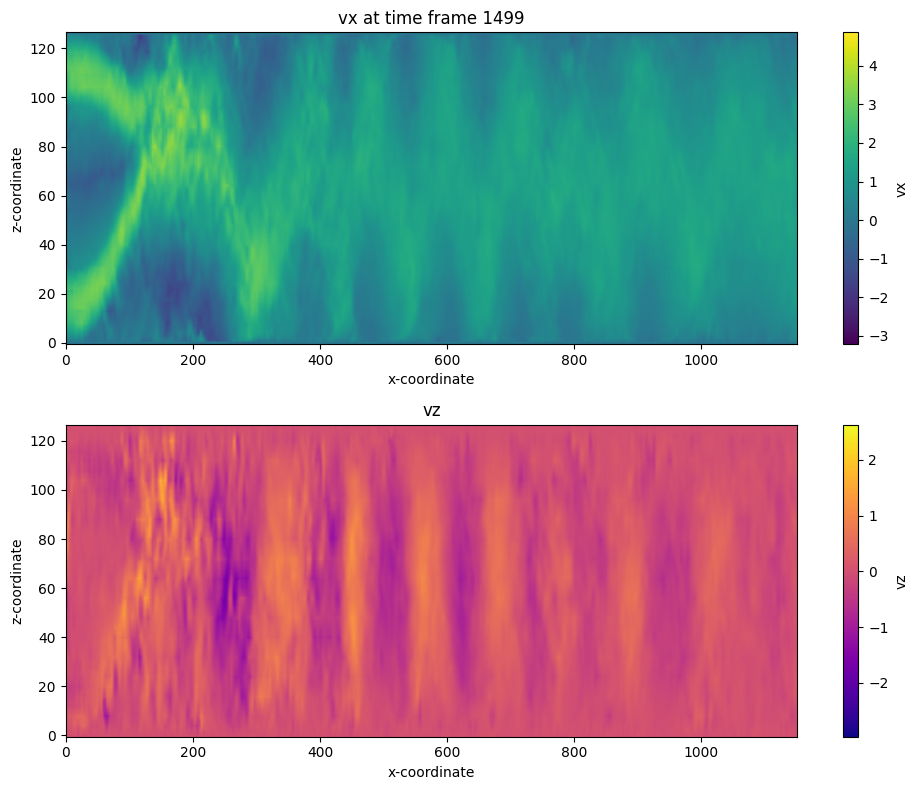

In [26]:
from matplotlib.animation import FuncAnimation, PillowWriter

n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = steady_state_prediction[0][0,:]
vz = steady_state_prediction[0][1,:]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = steady_state_prediction[frame][0,:]
    vz = steady_state_prediction[frame][1,:]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(1500),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_steadyF_10_1500B.gif", writer=writer)

plt.show()

In [ ]:
model.eval()
mse_list = []

with torch.no_grad():
    for x_t_true, x_t_plus_1_true in dataset:
        #vx_true = x_true[0]
        #vz_true = x_true[1]
        #plot_vx_vz(vx_true, vz_true)
        x_true = x_t_true.unsqueeze(0).to('cuda')
        x_pred = model(x_true).squeeze(0).cpu()
        #vx_pred = x_pred[0]
        #vz_pred = x_pred[1]
        #plot_vx_vz(vx_pred, vz_pred)
        #vx_diff = (vx_true - vx_pred)**2
        #vz_diff = (vz_true - vz_pred)**2
        mse_list.append(np.mean((x_true.to('cpu').numpy() - x_pred.numpy())**2))
        #plot_vx_vz(vx_diff, vz_diff)
        #print(np.sum(vz_diff.numpy()))
        #print(np.sum(vz_diff.numpy()))
        #print()
        ##

In [ ]:
mse_list = np.array(mse_list)

In [ ]:
np.mean(mse_list)

In [ ]:
mse_list

In [ ]:
len(dataset)